In [1]:
from llama_index.core import SimpleDirectoryReader
from pathlib import Path
import numpy as np
import os

from experiments.rag_experiment import (
    RAGConfig, ChunkingConfig, EmbeddingConfig, RetrievalConfig, LLMConfig,
    EvalDataLoader, ExperimentRunner, ResultsVisualizer,
)

/home/yuri/HSE/ВКР/RAG/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Загрузка и подготовка данных

In [2]:
# Загрузка документов
local_data = Path.cwd() / "./data"
reader = SimpleDirectoryReader(input_dir=local_data, required_exts=[".pdf"])
docs = reader.load_data()

# Проставляем page_label до удаления пустых (чтобы номера совпадали с PDF)
for i, doc in enumerate(docs):
    doc.metadata["page_label"] = i + 1

# Удаляем пустые страницы
empty = [i for i, doc in enumerate(docs) if len(doc.text) == 0]
print(f"Пустые страницы: {[docs[i].metadata['page_label'] for i in empty]}")
for i in sorted(empty, reverse=True):
    docs.pop(i)
print(f"Документов после очистки: {len(docs)}")

# Загрузка eval-данных
SKIP_PAGES = {72, 73, 74, 75, 76, 77, 78, 79, 80, 81}  # справочные таблицы

eval_data = EvalDataLoader.load(
    path="./context/docs_questions_qwen3_14b_awq.jsonl",
    question_types=["simple", "medium", "complex"],  # все типы вопросов
    skip_pages=SKIP_PAGES,
)

2026-04-09 10:50:47,700 - INFO - Загружено 222 вопросов из ./context/docs_questions_qwen3_14b_awq.jsonl


Пустые страницы: [34, 86]
Документов после очистки: 84


### Создаём runner

In [3]:
runner = ExperimentRunner(
    docs=docs,
    eval_data=eval_data,
    embed_model_name="Qwen/Qwen3-Embedding-0.6B",
)



2026-04-09 10:50:50,046 - INFO - Загрузка токенизатора: Qwen/Qwen3-Embedding-0.6B


### Эксперимент 1. Подбор chunk size

In [ ]:
chunk_sizes = np.linspace(150, 3000, 17, dtype=int).tolist()

configs_chunk_size = [
    RAGConfig(
        name=f"token_{cs}_75",
        chunking=ChunkingConfig(chunk_size=cs, chunk_overlap=75, splitter_type="token"),
    )
    for cs in chunk_sizes
]

results_cs = await runner.run_all(
    configs=configs_chunk_size,
    save_csv= "./exp_results/exp1_chunk_size.csv",
)

runner.plot(x_col="chunk_size", title="Подбор chunk_size", save_path="./exp_results/exp1_chunk_size.png")

### Эксперимент 2. Подбор overlap

2026-04-08 18:52:50,906 - INFO - ============================================================
2026-04-08 18:52:50,906 - INFO - Эксперимент: token_506_50
2026-04-08 18:52:50,906 - INFO - ============================================================
2026-04-08 18:52:50,906 - INFO - Embedding: Qwen/Qwen3-Embedding-0.6B @ http://localhost:8081/v1
2026-04-08 18:52:52,174 - INFO - Создано 263 чанков (splitter=token, size=506, overlap=50)
Generating embeddings: 100%|██████████| 263/263 [00:01<00:00, 147.30it/s]
2026-04-08 18:52:54,161 - INFO - Коллекция wb_token_506_50 создана: 263 чанков
2026-04-08 18:52:54,922 - INFO -   token_506_50 | k= 1 | P=0.631 R=0.631 F1=0.631 HR=0.631 MRR=0.631
2026-04-08 18:52:54,924 - INFO -   token_506_50 | k= 2 | P=0.520 R=0.748 F1=0.596 HR=0.748 MRR=0.689
2026-04-08 18:52:54,925 - INFO -   token_506_50 | k= 3 | P=0.447 R=0.806 F1=0.553 HR=0.806 MRR=0.709
2026-04-08 18:52:54,927 - INFO -   token_506_50 | k= 5 | P=0.341 R=0.856 F1=0.467 HR=0.856 MRR=0.720
2026-04-

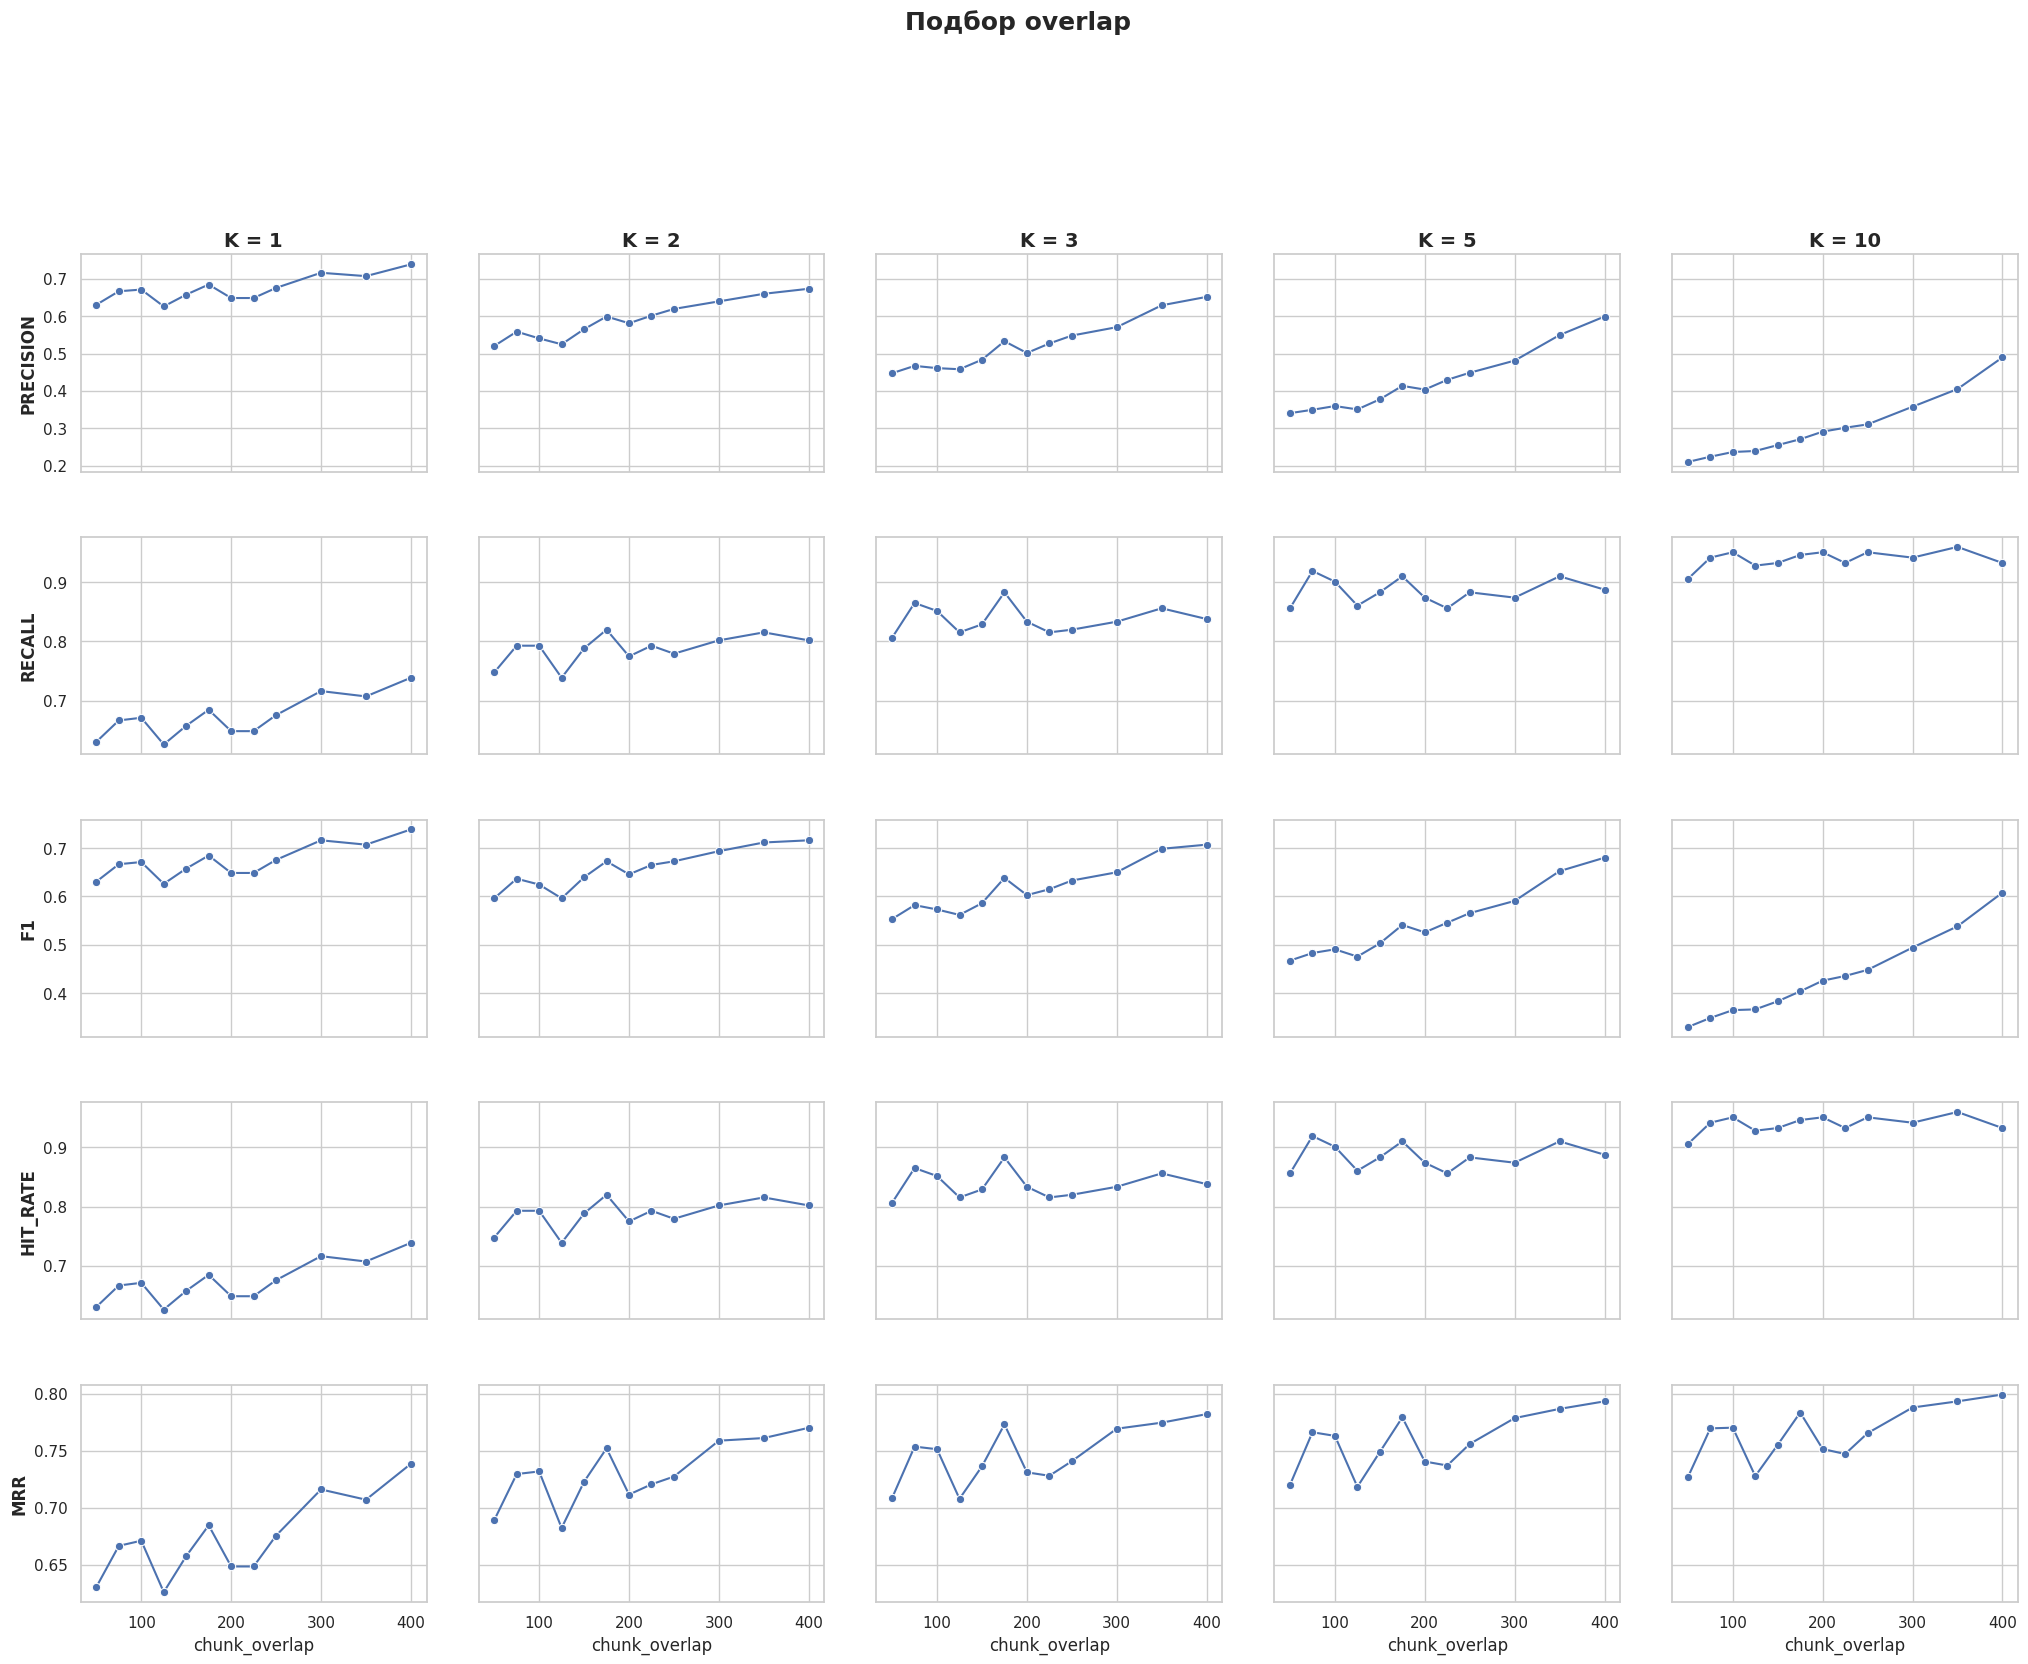

In [16]:
overlaps = [50, 75, 100, 125, 150, 175, 200, 225, 250, 300, 350, 400]

configs_overlap = [
    RAGConfig(
        name=f"token_506_{ov}",
        chunking=ChunkingConfig(chunk_size=506, chunk_overlap=ov, splitter_type="token"),
    )
    for ov in overlaps
]

results_ov = await runner.run_all(
    configs=configs_overlap,
    save_csv="./exp_results/exp2_overlap.csv",
)

runner.plot(x_col="chunk_overlap", title="Подбор overlap", save_path="./exp_results/exp2_overlap.png")

### Эксперимент 3. Сравнение сплиттеров

In [4]:
configs_splitters = [
    # TokenTextSplitter — baseline
    RAGConfig(
        name="token_506_175",
        chunking=ChunkingConfig(
            chunk_size=506, chunk_overlap=175, splitter_type="token",
        ),
        recreate=False
    ),
    # SentenceSplitter — старается не рвать предложения
    RAGConfig(
        name="sentence_506_175",
        chunking=ChunkingConfig(
            chunk_size=506, chunk_overlap=175, splitter_type="sentence",
        ),
        recreate=False,
    ),
    # SemanticSplitter — режет по смысловым границам
    # chunk_size/overlap НЕ используются, размер определяется автоматически
    RAGConfig(
        name="semantic_50",
        chunking=ChunkingConfig(
            splitter_type="semantic", breakpoint_percentile=90,
        ),
        recreate=False,
    ),
    # SemanticSplitter с другим порогом
    RAGConfig(
        name="semantic_75",
        chunking=ChunkingConfig(
            splitter_type="semantic", breakpoint_percentile=80,
        ),
        recreate=False,
    ),

    RAGConfig(
        name="hierar",
        chunking=ChunkingConfig(
            splitter_type="hierarchical"
        ),
        recreate=False,
    ),
]

results_sp = await runner.run_all(
    configs=configs_splitters,
    save_csv="./exp_results/exp3_splitters.csv",
)

# Для сравнения сплиттеров удобнее bar-plot или таблица,
# так как x-ось — категориальная
runner.compare(
    category_col="splitter_type",
    label_col="experiment",
    title="Сравнение сплиттеров",
    k_values=[1,2,3,5,10],
    save_path="./exp_results/exp3_bar_splitters.png",
)

2026-04-09 10:51:26,488 - INFO - ============================================================
2026-04-09 10:51:26,489 - INFO - Эксперимент: token_506_175
2026-04-09 10:51:26,489 - INFO - ============================================================


ValueError: 
******
Could not load OpenAI embedding model. If you intended to use OpenAI, please check your OPENAI_API_KEY.
Original error:
No API key found for OpenAI.
Please set either the OPENAI_API_KEY environment variable or openai.api_key prior to initialization.
API keys can be found or created at https://platform.openai.com/account/api-keys

Consider using embed_model='local'.
Visit our documentation for more embedding options: https://developers.llamaindex.ai/python/framework/module_guides/models/embeddings/
******